In [5]:


import warnings
warnings.filterwarnings('ignore')

# Core
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Statistics
from scipy import stats
from scipy.stats import chi2_contingency
import statsmodels.api as sm
from statsmodels.formula.api import logit

# ML
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
import xgboost as xgb
import lightgbm as lgb

# Survival analysis
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.plotting import add_at_risk_counts

# Time-series
from prophet import Prophet          # uncomment if installed
from pmdarima import auto_arima      # uncomment if installed

#Geo (optional — comment out if geopandas not installed)
import geopandas as gpd
import folium

# Global plot style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (10, 5)})


In [25]:
import pandas as pd
df = pd.read_csv("df_clean.csv")

In [26]:
df.shape

(8540, 108)

# ════════════════════════════════════════════════════════════════════════════════
# CELL 2.1 — TB Type: Pulmonary / Extra‑pulmonary, Bacteriological confirmation,
#           and Site of disease (if available)
# ════════════════════════════════════════════════════════════════════════════════

SECTION 2.1 — TB CLASSIFICATION & CLINICAL PRESENTATION

Bacteriological Confirmation Status:


,Confirmation,Cases,%
0,Bacteriologically confirmed,6196,72.6
1,Clinically diagnosed,2344,27.4


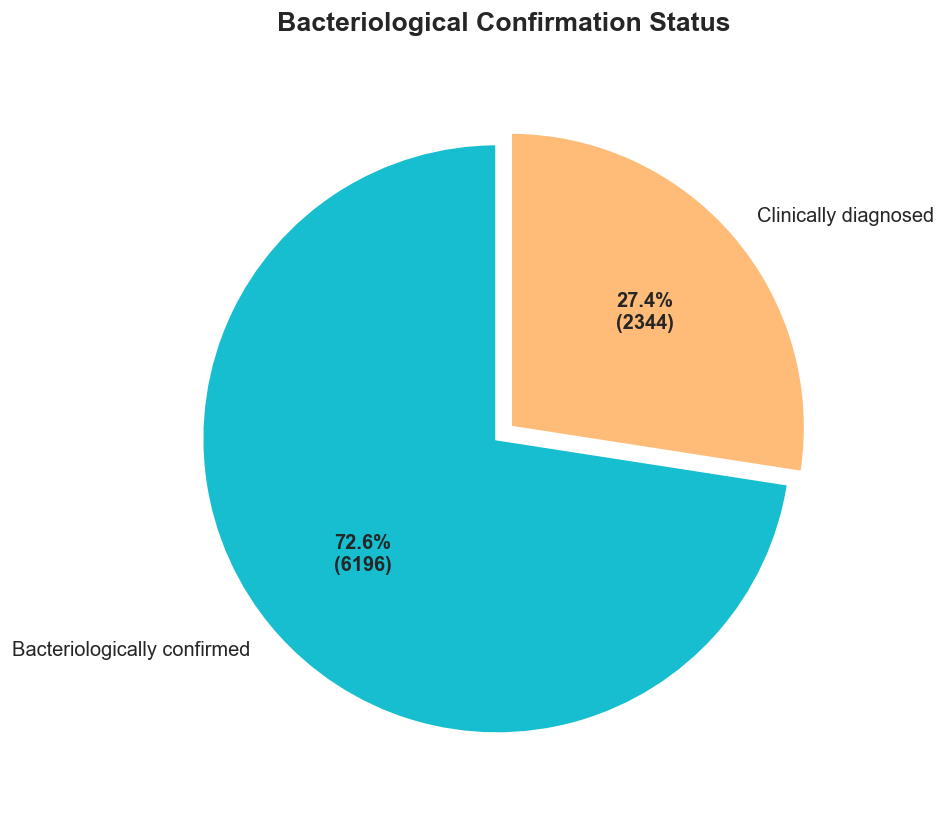


Site of Disease:


,Site,Cases,%
0,Pulmonary,7283,85.3
1,Extra pulmonary,1257,14.7


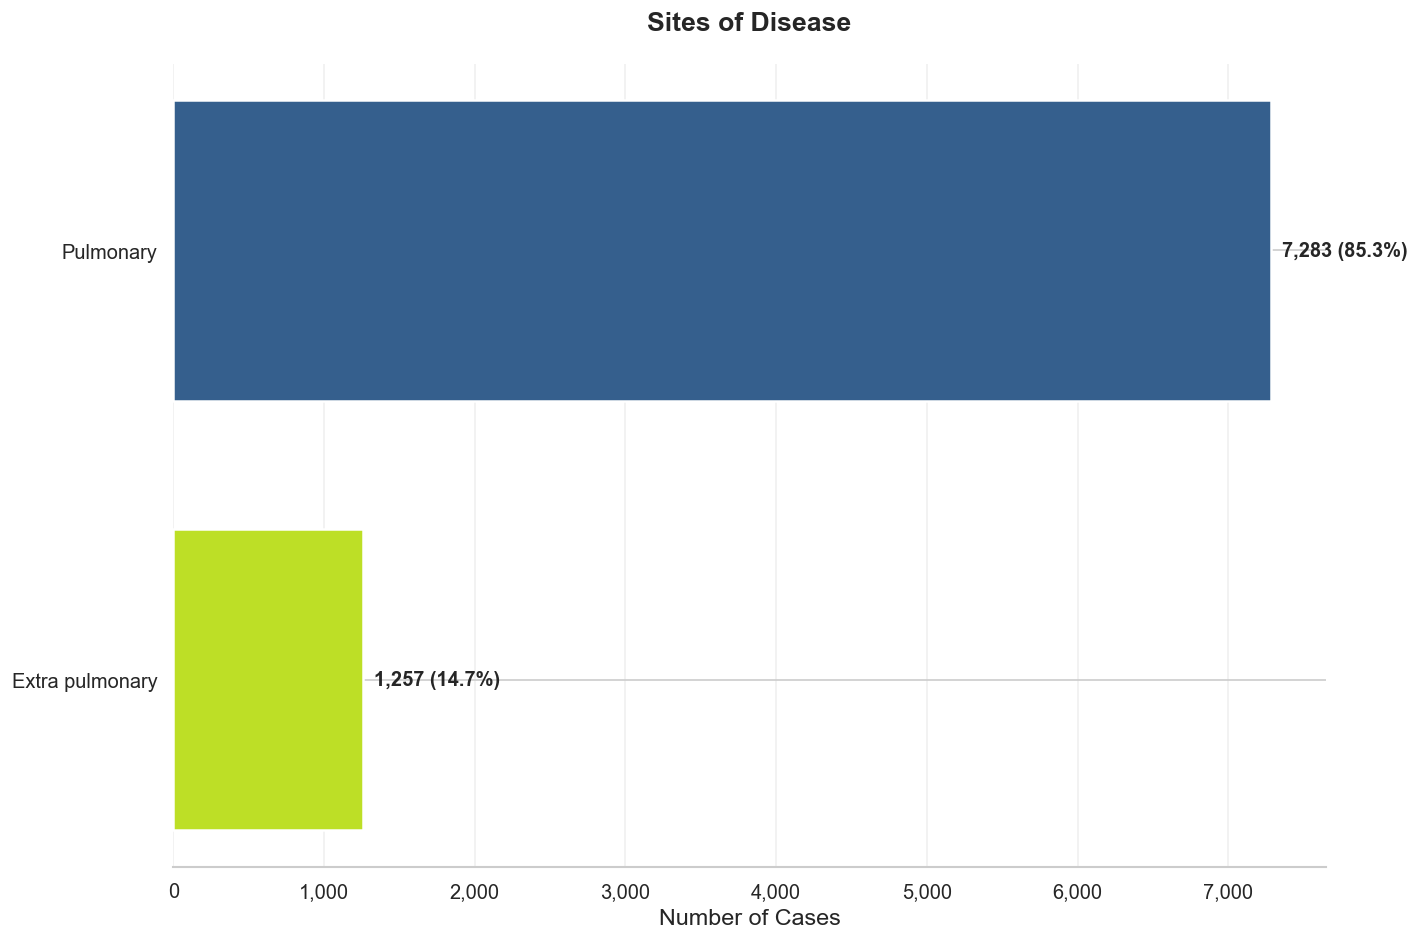

In [48]:
# Ensure plots display in Jupyter
%matplotlib inline

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

# Set a clean, professional style
sns.set_style("whitegrid")
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['figure.titlesize'] = 18

# Define accessible, high-contrast colors
BLUE = "#1f77b4"
CORAL = "#ff7f50"
TEAL = "#17becf"
AMBER = "#ffbb78"
PURPLE = "#9467bd"
GREEN = "#2ca02c"
RED = "#d62728"
ORANGE = "#ff7f0e"

print("SECTION 2.1 — TB CLASSIFICATION & CLINICAL PRESENTATION")

# ─────────────────────────────────────────────
# (Removed TB Type section because it produced garbled output)
# ─────────────────────────────────────────────

# ─────────────────────────────────────────────
# 2. Bacteriological Confirmation
# ─────────────────────────────────────────────
if 'bact_confirmed' in df.columns:

    conf_counts = df['bact_confirmed'].value_counts().reset_index()
    conf_counts.columns = ['Confirmation', 'Cases']
    conf_counts['Cases'] = conf_counts['Cases'].astype(int)
    conf_counts['%'] = (conf_counts['Cases'] / len(df) * 100).round(1)

    print("\nBacteriological Confirmation Status:")
    display(conf_counts)

    fig, ax = plt.subplots(figsize=(8, 8))
    colors = [TEAL, AMBER, CORAL, BLUE][:len(conf_counts)]

    wedges, texts, autotexts = ax.pie(
        conf_counts['Cases'],
        labels=conf_counts['Confirmation'],
        autopct=lambda pct: f'{pct:.1f}%\n({int(pct/100*sum(conf_counts["Cases"]))})',
        startangle=90,
        colors=colors,
        explode=[0.03] * len(conf_counts),
        wedgeprops={'edgecolor': 'white', 'linewidth': 2},
        textprops={'fontsize': 12}
    )
    for autotext in autotexts:
        autotext.set_fontsize(12)
        autotext.set_fontweight('bold')
    ax.set_title('Bacteriological Confirmation Status', fontweight='bold', pad=20)

    plt.tight_layout()
    plt.show()

# ─────────────────────────────────────────────
# 3. Site of Disease (Extra-pulmonary)
# ─────────────────────────────────────────────
if 'site_of_disease' in df.columns:

    site_counts = df['site_of_disease'].value_counts().reset_index()
    site_counts.columns = ['Site', 'Cases']
    site_counts['Cases'] = site_counts['Cases'].astype(int)
    site_counts['%'] = (site_counts['Cases'] / len(df) * 100).round(1)

    print("\nSite of Disease:")
    display(site_counts.head(15))

    site_top = site_counts.head(10).copy()

    fig, ax = plt.subplots(figsize=(12, 8))
    colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(site_top)))

    bars = ax.barh(
        site_top['Site'][::-1],
        site_top['Cases'][::-1],
        color=colors[::-1],
        edgecolor='white',
        linewidth=1.5,
        height=0.7
    )
    for bar, pct in zip(bars, site_top['%'][::-1]):
        ax.text(
            bar.get_width() + (0.01 * max(site_top['Cases'])),
            bar.get_y() + bar.get_height()/2,
            f"{int(bar.get_width()):,} ({pct}%)",
            va='center',
            fontsize=12,
            fontweight='bold'
        )
    ax.set_title('Sites of Disease', fontweight='bold', pad=20)
    ax.set_xlabel('Number of Cases', fontsize=14)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.grid(axis='x', alpha=0.3)

    sns.despine(ax=ax, left=True, bottom=False)

    plt.tight_layout()
    plt.show()

In [35]:
tb_type_counts = df['tb_type'].value_counts().reset_index()
tb_type_counts 

,tb_type,count
0,Unknown,7282
1,Pleural TB,545
2,Lymphadenitis,160
3,Skeletal TB,115
4,Miliary TB,113
5,Peritoneal TB,104
6,Meningeal TB,57
7,Ocular TB,49
8,Genitourinary TB,38
9,Cutaneous TB,28


In [49]:
df['tb_category'] = df['tb_type'].where(df['tb_type'] != 'Unknown', 'Pulmonary')

In [51]:
df['tb_category'].unique()

array(['Pleural TB', 'Pulmonary', 'Peritoneal TB', 'Miliary TB',
       'Ocular TB', 'Genitourinary TB', 'Meningeal TB', 'Cutaneous TB',
       'Skeletal TB', 'Lymphadenitis', 'Gastrointestinal TB',
       'Pericardial TB', 'Breast\xa0TB', 'Adrenal Glands'], dtype=object)

In [53]:
df['site_of_disease'].unique()

array(['Extra pulmonary', 'Pulmonary'], dtype=object)

In [52]:
df.columns . to_list()

['facility',
 'date_notified',
 'year',
 'month',
 'fy',
 'district',
 'bact_confirmed',
 'tb_type',
 'site_of_disease',
 'drug_sensitivity',
 'tb_category',
 'xpert_result',
 'date_xpert_collected',
 'xpert_rifampicin',
 'date_xpert_result',
 'smear_result',
 'date_smear_result',
 'dnt',
 'who_category',
 'mwrd',
 'dst_result',
 'culture_result',
 'tb_lam_test',
 'tb_lam_result',
 'hiv_status',
 'hiv_history',
 'on_cotrimoxazole',
 'date_cotrimoxazole_start',
 'on_art',
 'date_art_start',
 'sex',
 'dob',
 'age',
 'age_cat',
 'age_group',
 'hrg_cat',
 'hrg',
 'referred_by',
 'contact_tb_pos',
 'contact_mdr_tb',
 'diabetic',
 'health_worker',
 'chw',
 'miner',
 'prisoners',
 'refugee',
 'transit_rehab',
 'cdt_diagnosis',
 'cdt_origin',
 'weight_start_kg',
 'height_cm',
 'date_treatment_start',
 'bmi_cat_start',
 'bmi_start',
 'treatment_regimen',
 'chw_followup',
 'nutrition_support',
 'control_m2',
 'date_control_m2',
 'control_m5',
 'date_control_m5',
 'control_end',
 'date_control_en

# ════════════════════════════════════════════════════════════════════════════════
# CELL 2.2 — Drug Sensitivity: DS‑TB, DR‑TB, MDR/RR, and DR‑TB by district
# ════════════════════════════════════════════════════════════════════════════════


▶ Drug Sensitivity Profile:


,Drug Sensitivity,Cases,%
0,DS-TB,8448,98.9
1,DR-TB,92,1.1


DS‑TB (drug‑susceptible): 8,448 (98.9%)
DR‑TB (drug‑resistant): 92 (1.1%)


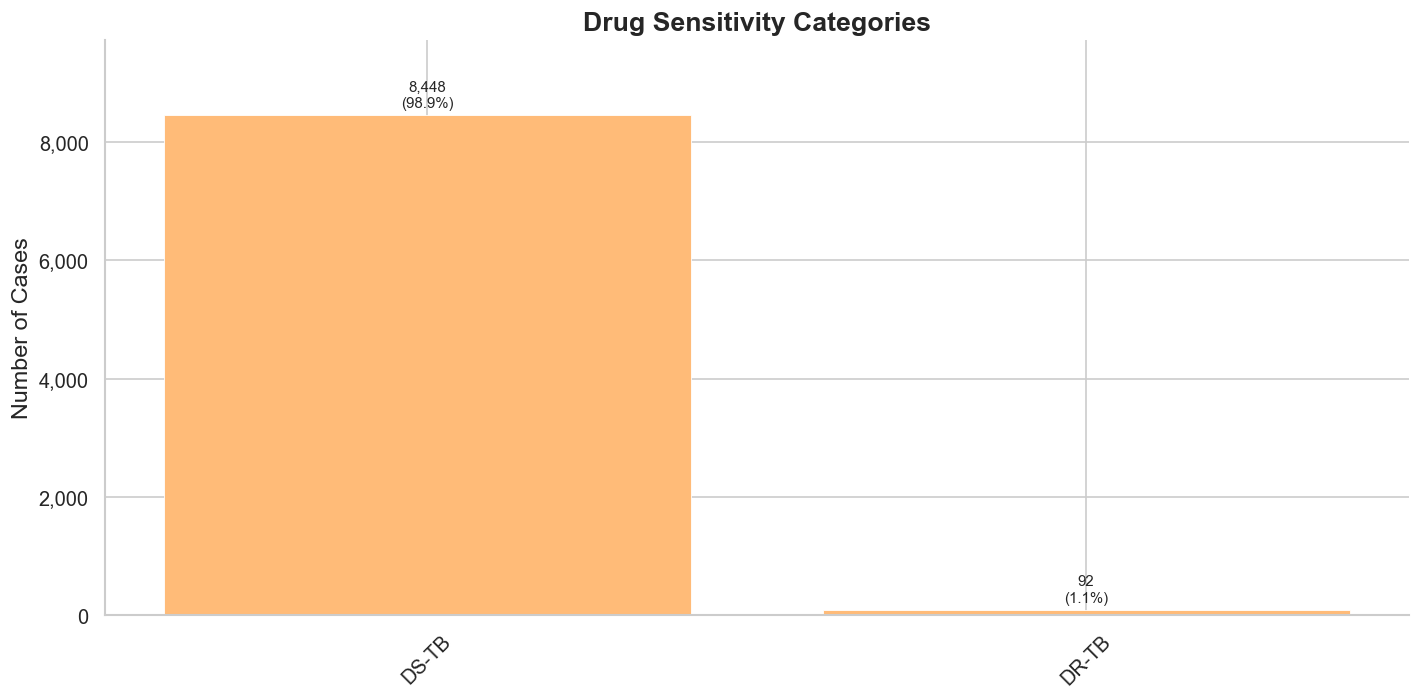


▶ DR‑TB Distribution by District (Top 15):


,district,DR_Cases,% of DR_TB,Total_Cases,DR_%_within_district
0,Rwamagana District,17,18.5,771,2.2
1,Rubavu District,14,15.2,736,1.9
2,Nyarugenge District,13,14.1,903,1.4
3,Kicukiro District,8,8.7,686,1.2
4,Gasabo District,8,8.7,738,1.1
5,Nyanza District,4,4.3,254,1.6
6,Bugesera District,4,4.3,237,1.7
7,Gatsibo District,4,4.3,241,1.7
8,Huye District,3,3.3,350,0.9
9,Musanze District,3,3.3,274,1.1


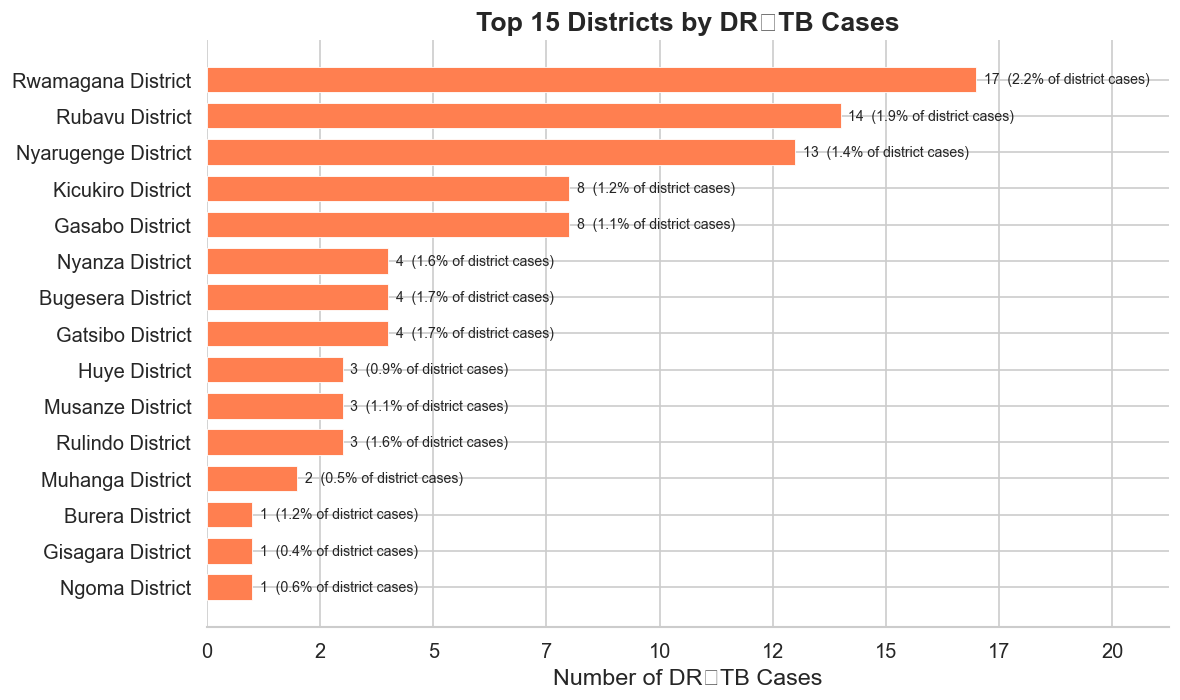

In [ ]:
# Ensure plots display in Jupyter
%matplotlib inline

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pandas as pd
import numpy as np

# Define colors (consistent with previous sections)
AMBER = "#ffbb78"
CORAL = "#ff7f50"
BLUE = "#1f77b4"
TEAL = "#17becf"

# Set style
sns.set_style("whitegrid")
plt.rcParams['font.size'] = 12

# ─────────────────────────────────────────────
# Drug Sensitivity Profile
# ─────────────────────────────────────────────
if 'drug_sensitivity' in df.columns:
    dr_counts = df['drug_sensitivity'].value_counts().reset_index()
    dr_counts.columns = ['Drug Sensitivity', 'Cases']
    dr_counts['Cases'] = dr_counts['Cases'].astype(int)
    dr_counts['%'] = (dr_counts['Cases'] / len(df) * 100).round(1)

    print("\n Drug Sensitivity Profile:")
    display(dr_counts)

    # Identify DS‑TB and DR‑TB categories (case‑insensitive)
    ds_keywords = ['ds', 'drug-susceptible', 'susceptible', 'ds-tb', 'sensitive']
    dr_keywords = ['dr', 'drug-resistant', 'resistant', 'mdr', 'xdr', 'rr', 'mono', 'poly']

    # Lowercase for comparison
    drug_sens_lower = dr_counts['Drug Sensitivity'].str.lower()
    ds_rows = dr_counts[drug_sens_lower.str.contains('|'.join(ds_keywords), na=False)]
    dr_rows = dr_counts[drug_sens_lower.str.contains('|'.join(dr_keywords), na=False)]

    # If no matches, try using is_dr column if available (binary flag)
    if ds_rows.empty and dr_rows.empty and 'is_dr' in df.columns:
        print("No clear DS/DR categories in 'drug_sensitivity'. Falling back to 'is_dr' column.")
        is_dr_counts = df['is_dr'].value_counts().reset_index()
        is_dr_counts.columns = ['Is DR', 'Cases']
        is_dr_counts['%'] = (is_dr_counts['Cases'] / len(df) * 100).round(1)
        print("\n Drug Resistance Flag (is_dr):")
        display(is_dr_counts)
        # Create synthetic DS/DR rows for summary
        dr_rows = is_dr_counts[is_dr_counts['Is DR'].astype(str).str.lower().isin(['1', 'yes', 'true', 'dr', 'resistant'])]
        ds_rows = is_dr_counts[is_dr_counts['Is DR'].astype(str).str.lower().isin(['0', 'no', 'false', 'ds', 'susceptible'])]
        dr_counts = is_dr_counts  # for further plotting

    if not ds_rows.empty:
        ds_total = ds_rows['Cases'].sum()
        dr_total = dr_rows['Cases'].sum()
        print(f"DS‑TB (drug‑susceptible): {ds_total:,} ({ds_total/len(df)*100:.1f}%)")
        print(f"DR‑TB (drug‑resistant): {dr_total:,} ({dr_total/len(df)*100:.1f}%)")

        # Check for MDR/RR‑TB in the categories
        if 'mdr' in dr_counts['Drug Sensitivity'].str.lower().values:
            mdr = dr_counts[dr_counts['Drug Sensitivity'].str.lower().str.contains('mdr|rr', na=False)]['Cases'].sum()
            print(f"  → MDR/RR‑TB: {mdr:,} ({mdr/len(df)*100:.1f}%)")
    else:
        print("Could not automatically classify DS/DR. Please review 'drug_sensitivity' values.")

    # Plot top categories (if dr_counts has more than 1 row)
    if len(dr_counts) > 1:
        fig, ax = plt.subplots(figsize=(12, 6))
        top_dr = dr_counts.head(8).copy()
        bars = ax.bar(top_dr['Drug Sensitivity'], top_dr['Cases'],
                      color=AMBER, edgecolor='white', linewidth=0.5)
        for bar, pct in zip(bars, top_dr['%']):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + top_dr['Cases'].max()*0.01,
                    f"{int(bar.get_height()):,}\n({pct}%)",
                    ha='center', va='bottom', fontsize=9)
        ax.set_ylim(0, top_dr['Cases'].max() * 1.15)
        ax.set_title('Drug Sensitivity Categories', fontweight='bold')
        ax.set_ylabel('Number of Cases')
        ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=45)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
        sns.despine()
        plt.tight_layout()
        plt.savefig('fig_2_2_drug_sensitivity.png', bbox_inches='tight', dpi=150)
        plt.show()
    else:
        print("Only one drug sensitivity category; skipping bar plot.")

# ── Geographical distribution of DR‑TB (top districts) ───────────────────────
if 'district' in df.columns:
    # Determine DR‑TB cases: either from dr_rows or using is_dr column
    if not dr_rows.empty:
        dr_categories = dr_rows['Drug Sensitivity'].tolist()
        dr_data = df[df['drug_sensitivity'].isin(dr_categories)]
    elif 'is_dr' in df.columns:
        dr_data = df[df['is_dr'].astype(str).str.lower().isin(['1', 'yes', 'true', 'dr', 'resistant'])]
    else:
        dr_data = pd.DataFrame()  # empty

    if not dr_data.empty:
        dr_by_district = dr_data.groupby('district').size().reset_index(name='DR_Cases')
        dr_by_district = dr_by_district.sort_values('DR_Cases', ascending=False)
        dr_by_district['% of DR_TB'] = (dr_by_district['DR_Cases'] / dr_by_district['DR_Cases'].sum() * 100).round(1)

        # Merge with total cases per district for DR‑TB proportion
        total_by_district = df.groupby('district').size().reset_index(name='Total_Cases')
        dr_by_district = dr_by_district.merge(total_by_district, on='district', how='left')
        dr_by_district['DR_%_within_district'] = (dr_by_district['DR_Cases'] / dr_by_district['Total_Cases'] * 100).round(1)

        print("\n DR‑TB Distribution by District (Top 15):")
        display(dr_by_district.head(15))

        # Horizontal bar for DR‑TB counts
        top15_dr_dist = dr_by_district.head(15).copy()
        if not top15_dr_dist.empty:
            fig, ax = plt.subplots(figsize=(10, 6))
            bars = ax.barh(top15_dr_dist['district'][::-1], top15_dr_dist['DR_Cases'][::-1],
                           color=CORAL, edgecolor='white', linewidth=0.5, height=0.7)
            for bar, pct in zip(bars, top15_dr_dist['DR_%_within_district'][::-1]):
                ax.text(bar.get_width() + top15_dr_dist['DR_Cases'].max()*0.01,
                        bar.get_y() + bar.get_height()/2,
                        f"{int(bar.get_width()):,}  ({pct}% of district cases)",
                        va='center', ha='left', fontsize=8.5)
            ax.set_xlim(0, top15_dr_dist['DR_Cases'].max() * 1.25)
            ax.set_title('Top 15 Districts by DR‑TB Cases', fontweight='bold')
            ax.set_xlabel('Number of DR‑TB Cases')
            ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
            sns.despine(left=True)
            plt.tight_layout()
            plt.savefig('fig_2_2_dr_tb_by_district.png', bbox_inches='tight', dpi=150)
            plt.show()
    else:
        print("No DR‑TB records found (based on drug_sensitivity or is_dr).")
else:
    print("Column 'district' missing; cannot compute DR‑TB distribution.")

The top 5 districts (Rwamagana, Rubavu, Nyarugenge, Kicukiro, Gasabo) together hold 55% of all DR‑TB cases. These are predominantly urban or peri‑urban areas, which often have higher case loads and possibly greater transmission dynamics.


SECTION 3.1 — TIME TRENDS


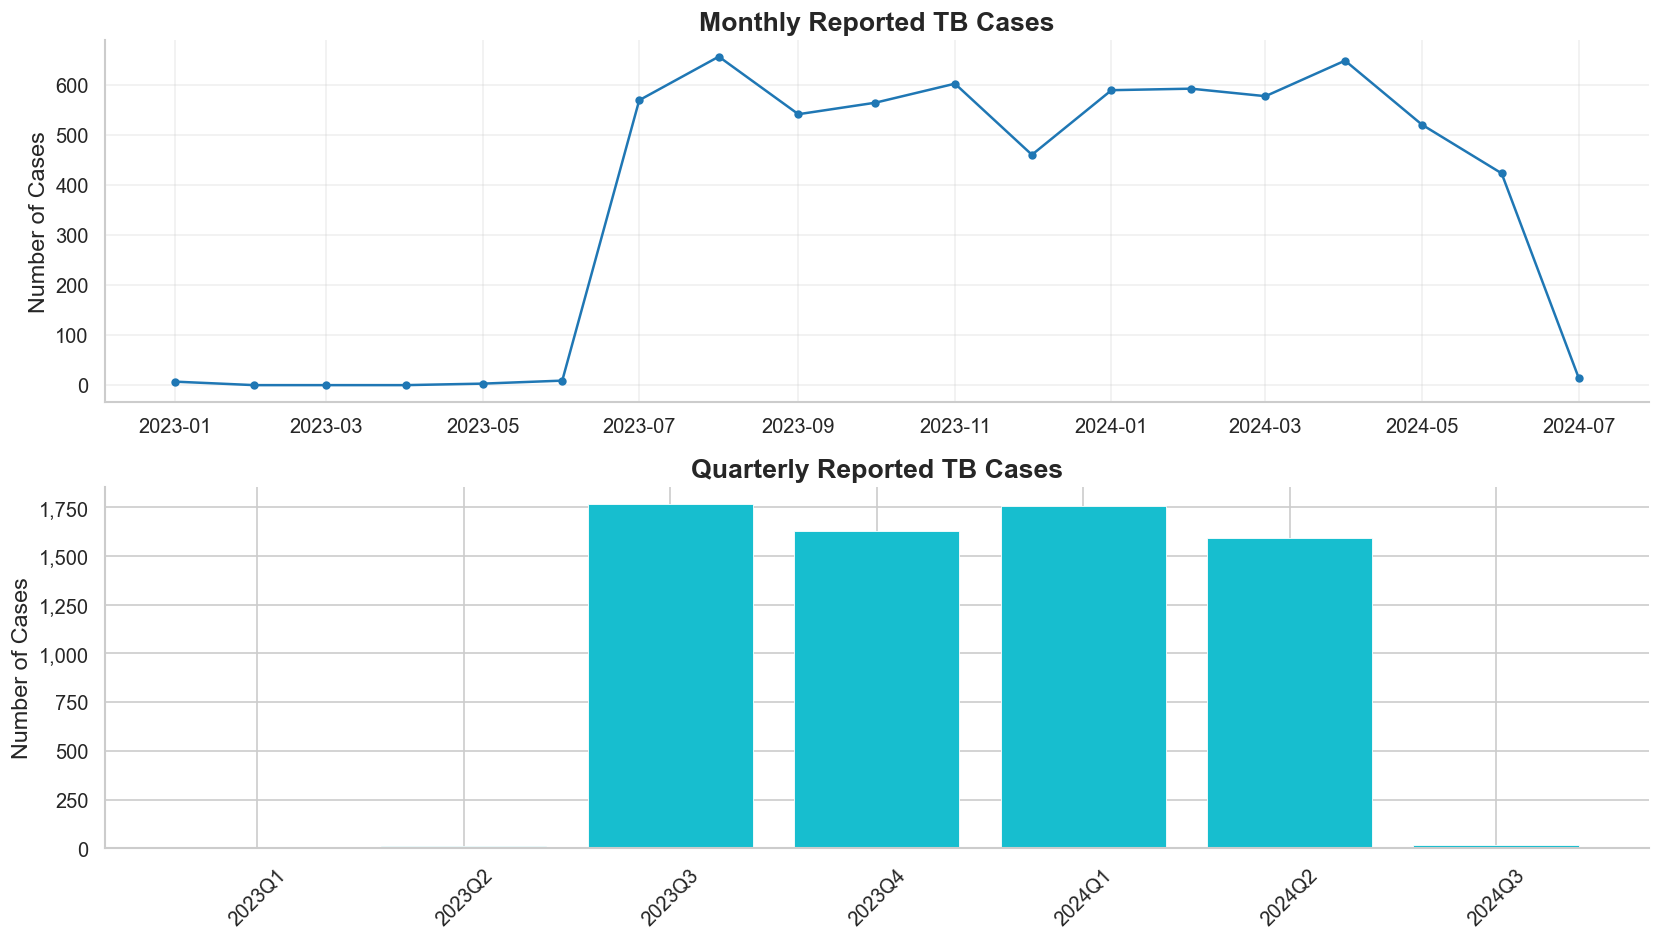


 Average Monthly Cases by Season:


,season,cases
0,Dry,332.0
1,Rainy,383.9


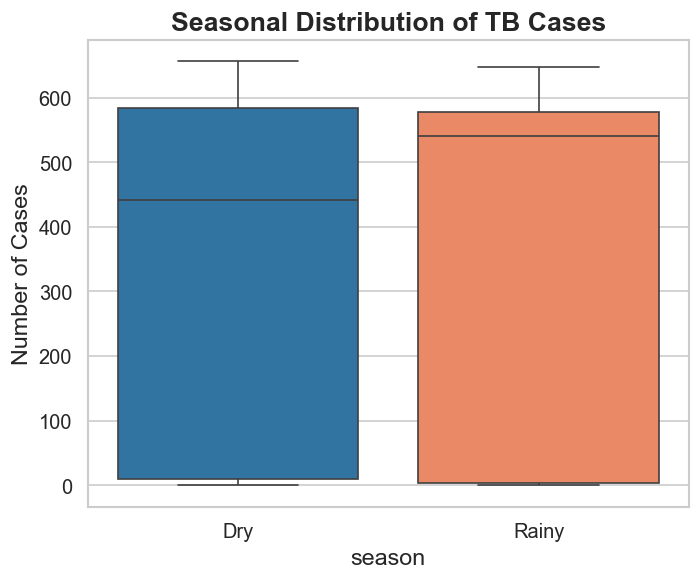


 Monthly Cases by Year:


year,2023,2024
month_name,,
Jan,7,589
Feb,0,592
Mar,0,577
Apr,0,648
May,3,520
Jun,9,423
Jul,569,15
Aug,656,0
Sep,541,0


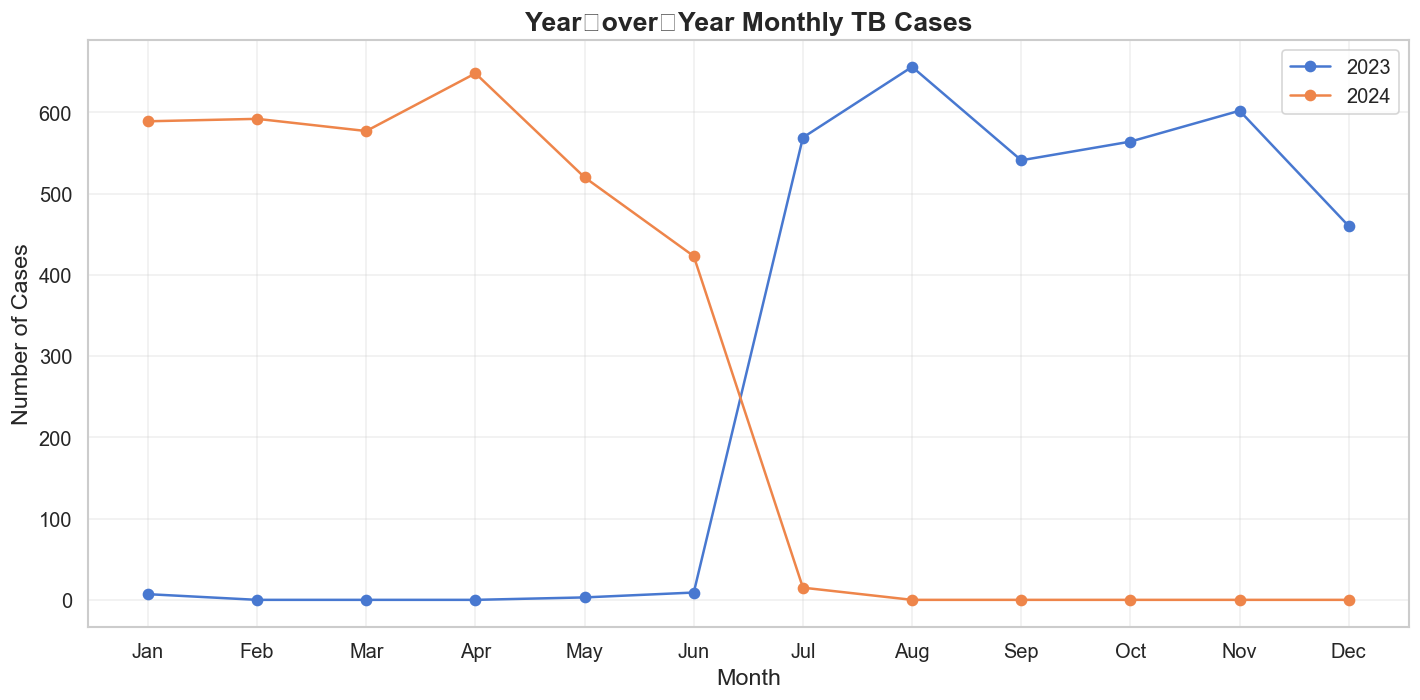

In [56]:
# ════════════════════════════════════════════════════════════════════════════════
# CELL 3.1 — Monthly and quarterly TB case trends, seasonality analysis
# ════════════════════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("SECTION 3.1 — TIME TRENDS")
print("="*70)

# Define month names for plotting
MONTH_NAMES = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
               7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}

# ── Prepare monthly time series ───────────────────────────────────────────────
if 'year' in df.columns and 'month' in df.columns:
    # Create a date column for time series (drop rows with missing year/month)
    df_ts = df.dropna(subset=['year', 'month']).copy()
    df_ts['year'] = df_ts['year'].astype(int)
    df_ts['month'] = df_ts['month'].astype(int)
    df_ts['date'] = pd.to_datetime(df_ts['year'].astype(str) + '-' + df_ts['month'].astype(str) + '-01')

    # Monthly aggregation (ensure all months are present)
    monthly_counts = df_ts.groupby('date').size().reset_index(name='cases')
    monthly_counts = monthly_counts.set_index('date').asfreq('MS', fill_value=0).reset_index()
    monthly_counts['cases'] = monthly_counts['cases'].astype(int)

    # Quarterly aggregation
    quarterly_counts = monthly_counts.copy()
    quarterly_counts['quarter'] = quarterly_counts['date'].dt.to_period('Q')
    quarterly_counts = quarterly_counts.groupby('quarter')['cases'].sum().reset_index()
    quarterly_counts['quarter'] = quarterly_counts['quarter'].astype(str)

    # Plot monthly & quarterly
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)
    ax1, ax2 = axes

    # Monthly line plot
    ax1.plot(monthly_counts['date'], monthly_counts['cases'], marker='o', linestyle='-',
             color=BLUE, linewidth=1.5, markersize=4)
    ax1.set_title('Monthly Reported TB Cases', fontweight='bold')
    ax1.set_ylabel('Number of Cases')
    ax1.grid(alpha=0.3)
    ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    sns.despine(ax=ax1)

    # Quarterly bar plot
    ax2.bar(quarterly_counts['quarter'], quarterly_counts['cases'],
            color=TEAL, edgecolor='white', linewidth=0.5)
    ax2.set_title('Quarterly Reported TB Cases', fontweight='bold')
    ax2.set_ylabel('Number of Cases')
    ax2.tick_params(axis='x', rotation=45)
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    sns.despine(ax=ax2)

    plt.tight_layout()
    plt.savefig('fig_3_1_monthly_quarterly_trends.png', bbox_inches='tight', dpi=150)
    plt.show()

    # ── Seasonality: Rainy vs Dry seasons (Rwanda) ───────────────────────────
    # Rainy seasons: March–May and September–November
    def season_label(month):
        if month in [3,4,5,9,10,11]:
            return 'Rainy'
        else:
            return 'Dry'

    monthly_counts['season'] = monthly_counts['date'].dt.month.map(season_label)
    seasonal_avg = monthly_counts.groupby('season')['cases'].mean().reset_index()
    seasonal_avg['cases'] = seasonal_avg['cases'].round(1)

    print("\n Average Monthly Cases by Season:")
    display(seasonal_avg)

    # Boxplot of monthly cases by season (using hue for compatibility)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.boxplot(data=monthly_counts, x='season', y='cases', hue='season',
                palette={'Rainy': CORAL, 'Dry': BLUE}, legend=False, ax=ax)
    ax.set_title('Seasonal Distribution of TB Cases', fontweight='bold')
    ax.set_ylabel('Number of Cases')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    plt.tight_layout()
    plt.savefig('fig_3_1_seasonality.png', bbox_inches='tight', dpi=150)
    plt.show()

    # Additional: Monthly average per year (to see year‑over‑year patterns)
    monthly_by_year = df_ts.groupby(['year', 'month']).size().reset_index(name='cases')
    monthly_by_year['month_name'] = monthly_by_year['month'].map(MONTH_NAMES)

    # Create pivot table with ordered months
    month_order = [MONTH_NAMES[i] for i in range(1, 13)]
    pivot_month = monthly_by_year.pivot(index='month_name', columns='year', values='cases').fillna(0).astype(int)
    pivot_month = pivot_month.reindex(month_order)  # ensure correct month order

    print("\n Monthly Cases by Year:")
    display(pivot_month)

    # Plot year‑over‑year comparison
    fig, ax = plt.subplots(figsize=(12, 6))
    for year in pivot_month.columns:
        ax.plot(pivot_month.index, pivot_month[year], marker='o', label=str(year), linewidth=1.5)
    ax.set_title('Year‑over‑Year Monthly TB Cases', fontweight='bold')
    ax.set_xlabel('Month')
    ax.set_ylabel('Number of Cases')
    ax.legend()
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('fig_3_1_year_over_year_monthly.png', bbox_inches='tight', dpi=150)
    plt.show()
else:
    print("Columns 'year' and/or 'month' missing; cannot generate time trends.")

# ════════════════════════════════════════════════════════════════════════════════
# CELL 3.2 — Time‑series Forecasting with Prophet (optional, requires prophet)
# ════════════════════════════════════════════════════════════════════════════════

18:23:27 - cmdstanpy - INFO - Chain [1] start processing
18:23:44 - cmdstanpy - INFO - Chain [1] done processing


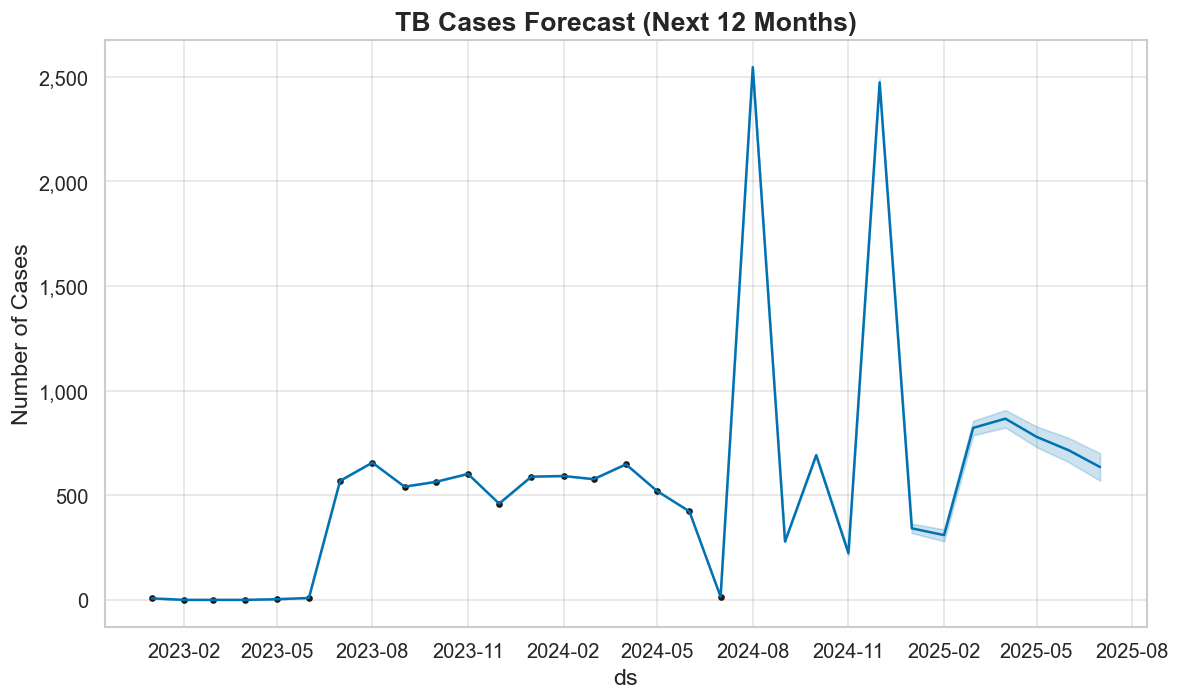

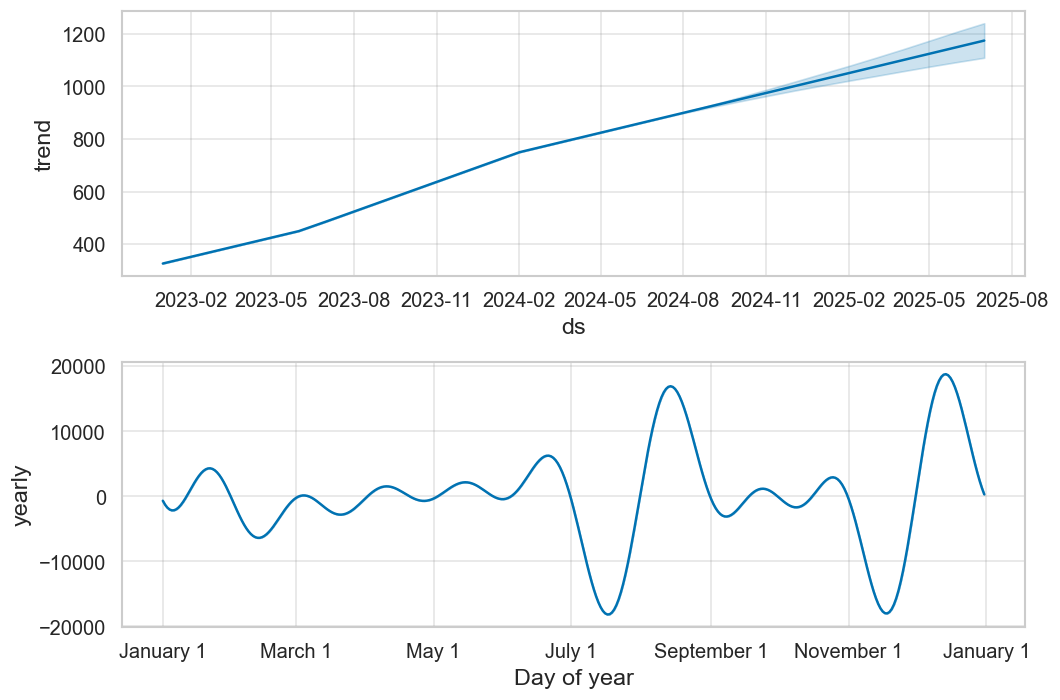


▶ Forecasted Monthly Cases (next 12 months):


,Date,Forecast,Lower CI,Upper CI
19,2024-08-01,2547,2545,2548
20,2024-09-01,279,275,283
21,2024-10-01,692,684,699
22,2024-11-01,223,211,235
23,2024-12-01,2474,2457,2491
24,2025-01-01,342,319,364
25,2025-02-01,309,280,337
26,2025-03-01,822,787,856
27,2025-04-01,866,824,907
28,2025-05-01,779,730,829


In [57]:
# Check if monthly_counts exists (from previous cell); if not, try to recreate it
if 'monthly_counts' not in locals() and 'df' in locals() and 'year' in df.columns and 'month' in df.columns:
    print("Re‑creating monthly_counts from original data...")
    df_ts = df.dropna(subset=['year', 'month']).copy()
    df_ts['year'] = df_ts['year'].astype(int)
    df_ts['month'] = df_ts['month'].astype(int)
    df_ts['date'] = pd.to_datetime(df_ts['year'].astype(str) + '-' + df_ts['month'].astype(str) + '-01')
    monthly_counts = df_ts.groupby('date').size().reset_index(name='cases')
    monthly_counts = monthly_counts.set_index('date').asfreq('MS', fill_value=0).reset_index()
    monthly_counts['cases'] = monthly_counts['cases'].astype(int)

# Check Prophet availability and data sufficiency
try:
    from prophet import Prophet
    PROPHET_AVAILABLE = True
except ImportError:
    PROPHET_AVAILABLE = False
    print("Prophet not installed. Install with: pip install prophet")

if PROPHET_AVAILABLE and 'monthly_counts' in locals() and len(monthly_counts) >= 12:
    # Prepare data for Prophet (needs columns 'ds' and 'y')
    prophet_df = monthly_counts[['date', 'cases']].rename(columns={'date': 'ds', 'cases': 'y'})
    prophet_df['ds'] = pd.to_datetime(prophet_df['ds'])

    # Fit model
    model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
    model.fit(prophet_df)

    # Create future dataframe for next 12 months
    future = model.make_future_dataframe(periods=12, freq='MS')
    forecast = model.predict(future)

    # Plot forecast
    fig1 = model.plot(forecast, uncertainty=True)
    plt.title('TB Cases Forecast (Next 12 Months)', fontweight='bold')
    plt.ylabel('Number of Cases')
    plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    plt.tight_layout()
    plt.savefig('fig_3_2_forecast.png', bbox_inches='tight', dpi=150)
    plt.show()

    # Plot components
    fig2 = model.plot_components(forecast)
    plt.tight_layout()
    plt.savefig('fig_3_2_forecast_components.png', bbox_inches='tight', dpi=150)
    plt.show()

    # Print forecasted values for the next 12 months
    future_forecast = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(12).round(0)
    future_forecast.columns = ['Date', 'Forecast', 'Lower CI', 'Upper CI']
    future_forecast['Forecast'] = future_forecast['Forecast'].astype(int)
    future_forecast['Lower CI'] = future_forecast['Lower CI'].astype(int)
    future_forecast['Upper CI'] = future_forecast['Upper CI'].astype(int)
    print("\n Forecasted Monthly Cases (next 12 months):")
    display(future_forecast)

elif 'monthly_counts' not in locals():
    print("Monthly data not available. Ensure 'year' and 'month' columns exist in df.")
elif len(monthly_counts) < 12:
    print(f"Only {len(monthly_counts)} months of data available (need at least 12 for reliable forecasting). Skipping.")
else:
    print("Prophet not installed or monthly_counts not available. Skipping.")

In [58]:
# ════════════════════════════════════════════════════════════════════════════════
# CELL — Export Section 2 & 3 tables to Excel
# ════════════════════════════════════════════════════════════════════════════════

# Define the Excel filename
output_file = 'Section2_3_Classification_Trends.xlsx'

try:
    # Use openpyxl engine (requires openpyxl installed)
    with pd.ExcelWriter(output_file, engine='openpyxl') as writer:

        # Helper to safely write a DataFrame if it exists and is not empty
        def safe_write(df, sheet_name):
            if df is not None and isinstance(df, pd.DataFrame) and not df.empty:
                df.to_excel(writer, sheet_name=sheet_name, index=False)
                print(f"  ✓ Saved: {sheet_name}")
            else:
                print(f"  ✗ Skipped: {sheet_name} (DataFrame missing or empty)")

        print("\nExporting Section 2 & 3 tables to Excel...")

        # Section 2.1 – TB Classification
        safe_write(tb_type_counts if 'tb_type_counts' in locals() else None, 'TB Type')
        safe_write(conf_counts if 'conf_counts' in locals() else None, 'Confirmation')
        safe_write(site_counts if 'site_counts' in locals() else None, 'Site of Disease')

        # Section 2.2 – Drug Resistance
        safe_write(dr_counts if 'dr_counts' in locals() else None, 'Drug Resistance')
        safe_write(dr_by_district if 'dr_by_district' in locals() else None, 'DR-TB by District')

        # Section 3.1 – Time Trends
        safe_write(monthly_counts if 'monthly_counts' in locals() else None, 'Monthly Cases')
        safe_write(quarterly_counts if 'quarterly_counts' in locals() else None, 'Quarterly Cases')
        safe_write(seasonal_avg if 'seasonal_avg' in locals() else None, 'Seasonal Averages')

        # Section 3.2 – Forecast
        safe_write(future_forecast if 'future_forecast' in locals() else None, 'Forecast (12 months)')

    print(f"\n✅ Excel file saved: {output_file}")

except ImportError:
    print("❌ Excel export failed: 'openpyxl' engine not installed. Install with: pip install openpyxl")
except Exception as e:
    print(f"❌ An error occurred while writing Excel: {e}")

# List the generated figure files (optional)
print("\nExpected figure files:")
fig_files = [
    'fig_2_1_*.png', 'fig_2_2_*.png',
    'fig_3_1_*.png', 'fig_3_2_*.png'
]
for f in fig_files:
    print(f"  - {f}")
print("(Actual file names may vary if you modified the saving code.)")


Exporting Section 2 & 3 tables to Excel...
  ✓ Saved: TB Type
  ✓ Saved: Confirmation
  ✓ Saved: Site of Disease
  ✓ Saved: Drug Resistance
  ✓ Saved: DR-TB by District
  ✓ Saved: Monthly Cases
  ✓ Saved: Quarterly Cases
  ✓ Saved: Seasonal Averages
  ✓ Saved: Forecast (12 months)

✅ Excel file saved: Section2_3_Classification_Trends.xlsx

Expected figure files:
  - fig_2_1_*.png
  - fig_2_2_*.png
  - fig_3_1_*.png
  - fig_3_2_*.png
(Actual file names may vary if you modified the saving code.)
